# Agrupamento por Densidade de Estações de Monitoramento da Rede Elétrica com PROC MODECLUS

## Resumo Executivo

Uma concessionária de distribuição de energia elétrica usa o PROC MODECLUS para encontrar
agrupamentos não paramétricos baseados em densidade entre suas estações de monitoramento
da rede (subestações e sensores de alimentador) a partir apenas das coordenadas no mapa.
O MODECLUS estima uma superfície de densidade sobre as estações e trata os clusters como
regiões de alta densidade separadas por lacunas de baixa densidade. Executá-lo em 90
estações simuladas com um raio de kernel uniforme de 3 km recupera os três bolsões de
serviço densos que embutimos nos dados como os três maiores clusters (24, 24 e 21
estações), enquanto as estações rurais dispersas caem em regiões esparsas e se separam em
seus próprios microclusters de uma e duas estações. Esse conjunto de estações isoladas é
o produto operacional: uma lista de candidatos de ativos remotos para a equipe de
planejamento de capital.

## Fontes de Dados

| Conjunto de dados | Linhas | Descrição |
|---------|------|-------------|
| `grid_sites` | 90 | Estações sintéticas de monitoramento de distribuição elétrica geradas inline com `call streaminit(70531)` e `rand()`. Três bolsões de serviço densos (CentroUrbano, Suburbano, Industrial) sorteados de normais bivariadas em torno de centroides distintos no mapa, além de 22 estações Rural dispersas sorteadas uniformemente pelo território. |

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `site_id` | Num | Identificador único da estação de monitoramento (1-90). |
| `region` | Char | Rótulo de planejamento que registra como cada estação foi gerada (CentroUrbano, Suburbano, Industrial, Rural); mantido fora do agrupamento. |
| `x_km`, `y_km` | Num | Localização da estação em quilômetros na grade de planejamento da concessionária; as variáveis de agrupamento. |
| `peak_load_mw` | Num | Carga máxima anual observada (MW) na estação; mantida para interpretação posterior. |

# Agrupamento por Densidade de Estações de Monitoramento da Rede

Uma concessionária regional de distribuição de energia elétrica opera uma rede de
**estações de monitoramento** -- subestações e sensores de alimentador -- espalhadas
por seu território de atendimento. Os planejadores querem agrupar essas estações em
**bolsões de serviço** naturais baseados puramente em geografia, sem pré-especificar
quantos grupos existem, e identificar **ativos rurais isolados** que não pertencem a
nenhum bolsão denso.

O `PROC MODECLUS` é bem adequado para isso: ele realiza um agrupamento *não paramétrico,
baseado em densidade*. Ele estima uma função de densidade sobre as estações e então
trata os clusters como regiões de alta densidade de estações separadas por lacunas de
baixa densidade. Os pontos esparsos isolados acabam em seus próprios clusters minúsculos
em vez de serem absorvidos por um bolsão -- exatamente o comportamento que queremos para
sinalizar estações remotas.

Este notebook:
1. Gera uma rede sintética realista de estações com 90 estações.
2. Estima a densidade das estações com um **kernel uniforme** e varre o raio de
   suavização `R=` para confirmar que os bolsões recuperados são estáveis.
3. Fixa um raio de trabalho, grava um conjunto de dados `OUT=` com a densidade e o
   rótulo de cluster de cada estação, e mapeia o resultado.

## Etapa 1 -- Gerar uma rede sintética de estações de monitoramento

Simulamos 90 estações. Três **bolsões de serviço** densos são sorteados de distribuições
normais bivariadas em torno de centroides distintos no mapa (CentroUrbano perto de
(12, 30), Suburbano perto de (30, 15), Industrial perto de (20, 42)), dando blocos
compactos de alta densidade com 24, 24 e 20 estações. Um quarto conjunto de 22 estações
**Rural** é sorteado uniformemente pelo território, produzindo as estações esparsas e
dispersas que uma concessionária trataria como isoladas.

O rótulo `region` registra como cada estação foi gerada; nós deliberadamente o
**mantemos fora** do agrupamento para que o MODECLUS redescubra a estrutura apenas a
partir das coordenadas. `peak_load_mw` é mantido para interpretação posterior.

In [1]:
DADOS grid_sites;
   CHAMAR streaminit(70531);
   COMPRIMENTO region $ 12;

   /* Bolsão de serviço urbano denso */
   FAZER site_id = 1 ATÉ 24;
      region = 'CentroUrbano';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      SAÍDA;
   FIM;

   /* Bolsão suburbano */
   FAZER site_id = 25 ATÉ 48;
      region = 'Suburbano';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      SAÍDA;
   FIM;

   /* Bolsão industrial (carga máxima maior) */
   FAZER site_id = 49 ATÉ 68;
      region = 'Industrial';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      SAÍDA;
   FIM;

   /* Estações rurais dispersas (esparsas, carga baixa) */
   FAZER site_id = 69 ATÉ 90;
      region = 'Rural';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      SAÍDA;
   FIM;
EXECUTAR;

TÍTULO 'Estações Sintéticas de Monitoramento da Rede';
PROCEDIMENTO MÉDIAS DADOS=grid_sites n mean std MIN MAX maxdec=2;
   CLASSE region;
   VARIÁVEL x_km y_km peak_load_mw;
   LABEL region="Região" x_km="X (km)" y_km="Y (km)" peak_load_mw="Carga Máxima (MW)";
EXECUTAR;

                                      Estações Sintéticas de Monitoramento da Rede                                      

                                                  The MEANS Procedure

                                            Analysis Variable : x_km X (km)

        Região                N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        CentroUrbano             24          12.07           1.34           8.65          14.42
        Industrial               20          20.36           0.96          18.52          21.53
        Rural                    22          29.79          10.62          11.06          47.45
        Suburbano                24          29.96           1.73          26.51          33.60
        ---------------------------------------------------------------------------------------

                                            Analysis Vari


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Estações Sintéticas de Monitoramento da Rede.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


As médias confirmam três bolsões apertados e um grupo difuso. As três regiões densas
têm desvios-padrão de coordenadas pequenos (cerca de 1-1.7 km em cada eixo) em torno de
centroides bem separados, enquanto o grupo Rural se espalha por toda a grade (desvios-
padrão acima de 10 km em ambos os eixos). A carga máxima também separa os bolsões --
as estações Industrial têm em média cerca de 6 MW, CentroUrbano cerca de 4.6 MW, Suburbano
cerca de 2.7 MW e Rural cerca de 1.5 MW -- o que é um contexto útil assim que os clusters
geográficos estão em mãos.

## Etapa 2 -- Agrupamento por densidade de kernel uniforme e varredura de raio

A estimação de densidade por kernel uniforme usa um **raio `R=`**: cada estação a até `R`
quilômetros contribui para a densidade local de uma estação. `R` pequeno dá uma
densidade irregular que fragmenta o território; `R` grande suaviza demais e funde os
bolsões. Um especialista em SAS nunca confia em um único valor -- ele varre uma faixa de
raios e procura uma contagem de clusters que seja **estável**, onde os bolsões densos
persistem enquanto apenas a contagem de pontos isolados dispersos varia.

Aqui `M=1` seleciona o método de agrupamento 1 (o método não paramétrico padrão), e
solicitamos raios `R=2.5 to 4 by 0.5` em uma única chamada. O MODECLUS executa a análise
uma vez para cada raio e reporta o número de clusters para cada um. `SHORT` suprime as
estatísticas detalhadas por cluster.

In [2]:
TÍTULO 'Agrupamento por Densidade de Kernel Uniforme das Estações da Rede';
title2 'Varredura de raio R = 2.5 a 4.0 km';

PROCEDIMENTO modeclus DADOS=grid_sites m=1 r=2.5 ATÉ 4 POR 0.5 short;
   VARIÁVEL x_km y_km;
   id site_id;
   LABEL x_km="X (km)" y_km="Y (km)" site_id="ID da Estação";
EXECUTAR;

                           Agrupamento por Densidade de Kernel Uniforme das Estações da Rede                            
                                           Varredura de raio R = 2.5 a 4.0 km                                           


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: X (km) Y (km)

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Agrupamento por Densidade de Kernel Uniforme das Estações da Rede.
NOTE: Option TITLE2 changed to Varredura de raio R = 2.5 a 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


A contagem de clusters se move apenas suavemente ao longo da varredura -- 23 clusters em
`R=2.5`, 22 em `R=3.0`, 19 em `R=3.5` e 18 em `R=4.0`. As contagens brutas altas vêm das
estações rurais dispersas: cada estação isolada fica em sua própria vizinhança esparsa e
forma um cluster de uma estação, então a maioria dos 18-23 "clusters" são singletons.
O que permanece constante por baixo é a estrutura que importa -- os três bolsões densos
permanecem três clusters grandes e bem separados em todos os raios. À medida que `R`
se alarga, alguns dos singletons dispersos se fundem com um vizinho ou um bolsão
próximo, e é por isso que a contagem total cai lentamente em vez de oscilar
descontroladamente. Essa estabilidade é o sinal de que a solução de três bolsões é
real e não um artefato de uma única largura de banda.

## Etapa 3 -- Solução final de cluster para mapeamento

Tendo visto que os três bolsões são estáveis ao longo da varredura, fixamos um único
raio de trabalho (`R=3` km) e solicitamos a opção **ALL** para a exibição completa por
cluster, além de **OUT=** para gravar as coordenadas originais junto com a estimativa
de `DENSITY` e a atribuição de `CLUSTER` para que possamos mapear o resultado. Os
clusters são numerados por densidade de moda decrescente, então os bolsões mais densos
são os clusters 1, 2 e 3, e as estações esparsas ficam com os números mais altos.

In [3]:
TÍTULO 'Solução Final de Cluster Baseada em Densidade';
title2 'Kernel uniforme, R = 3 km';

PROCEDIMENTO modeclus DADOS=grid_sites m=1 r=3 out=join_out ALL;
   VARIÁVEL x_km y_km;
   id site_id;
   LABEL x_km="X (km)" y_km="Y (km)" site_id="ID da Estação";
EXECUTAR;

                                     Solução Final de Cluster Baseada em Densidade                                      
                                               Kernel uniforme, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: X (km) Y (km)

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
  


NOTE: Option TITLE changed to Solução Final de Cluster Baseada em Densidade.
NOTE: Option TITLE2 changed to Kernel uniforme, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


O Resumo de Clusters torna a estrutura explícita. A solução `R=3` retorna
**22 clusters**, mas eles são fortemente escalonados por densidade:

- **Cluster 1** -- 24 estações, densidade de moda de cerca de 0.0090 (o bolsão
  CentroUrbano).
- **Cluster 2** -- 24 estações, densidade de moda de cerca de 0.0079 (o bolsão
  Suburbano).
- **Cluster 3** -- 21 estações, densidade de moda de cerca de 0.0079 (o bolsão
  Industrial; ele capta uma estação rural que caiu na sua borda).
- **Clusters 4-22** -- um grupo de três estações e dezoito clusters de uma única
  estação, todos com densidade de moda de cerca de 0.0004, cerca de vinte vezes mais
  esparsos que os bolsões.

Os três bolsões densos respondem por 69 das 90 estações; as 21 estações restantes são
os ativos rurais dispersos, cada um sozinho ou quase sozinho em uma vizinhança de baixa
densidade. A densidade, não uma contagem de cluster pré-definida, traça a linha entre
um bolsão de serviço e uma estação isolada.

## Etapa 4 -- Mapear os clusters

Marcamos cada estação conforme ela caiu em um dos três bolsões densos (`cluster <= 3`)
ou em um microcluster esparso, e então plotamos cada estação em suas coordenadas do
mapa coloridas por essa situação. Essa é a visão do planejador: bolsões densos a serem
geridos como territórios de serviço, e estações isoladas a serem sinalizadas para
tratamento separado.

                                   Bolsões de Serviço Recuperados e Estações Isoladas                                   
                                 Agrupamento por densidade de kernel uniforme, R = 3 km                                 




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Bolsões de Serviço Recuperados e Estações Isoladas.
NOTE: Option TITLE2 changed to Agrupamento por densidade de kernel uniforme, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


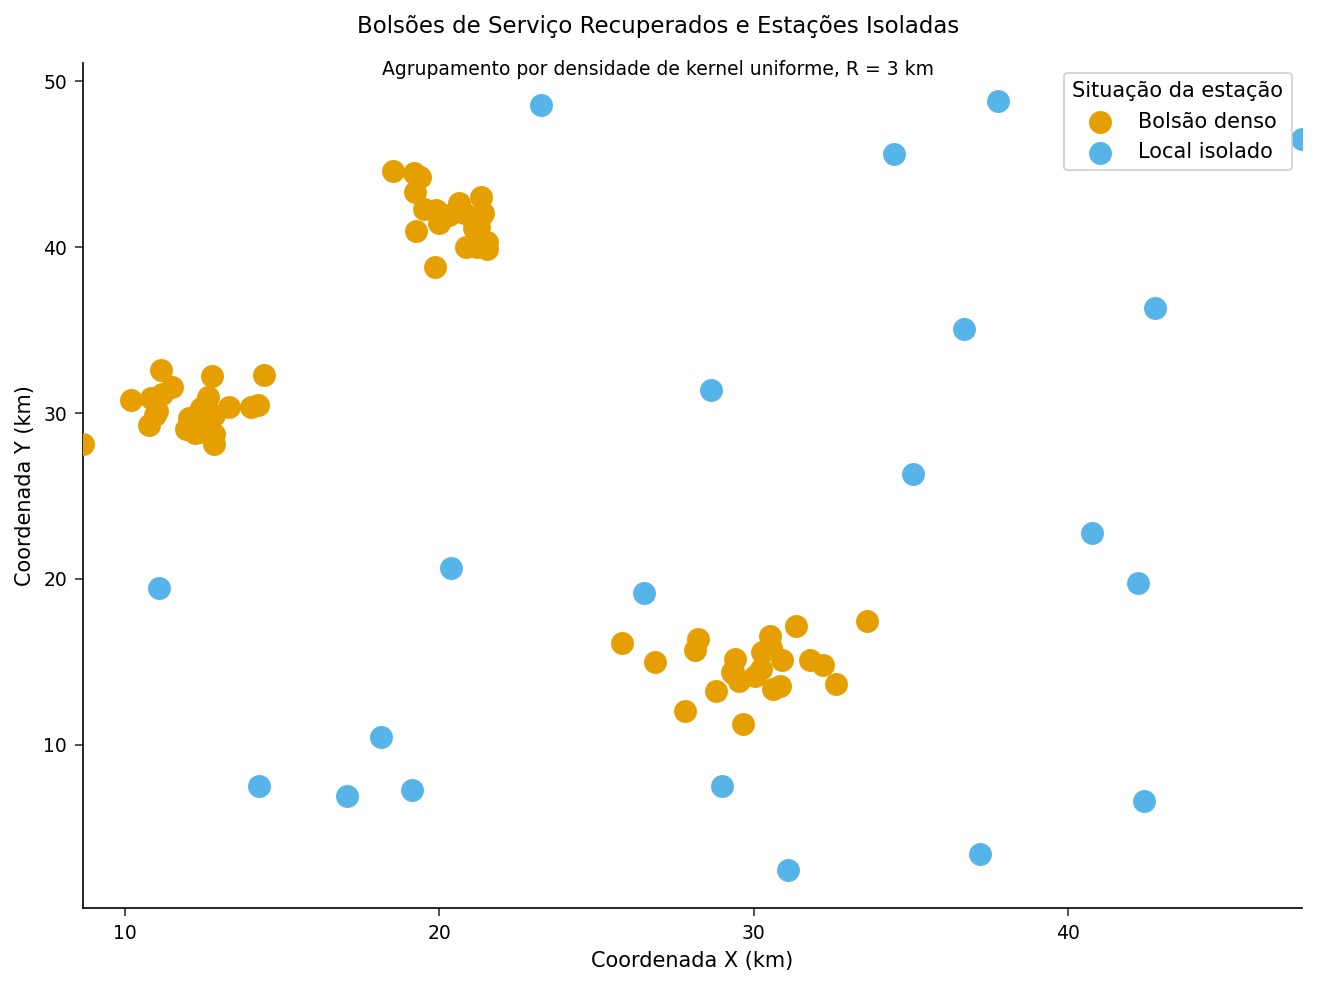

In [4]:
DADOS mapped;
   DEFINIR join_out;
   COMPRIMENTO status $ 16;
   SE CLUSTER <= 3 ENTÃO status = 'Bolsão denso';
   SENÃO status = 'Local isolado';
EXECUTAR;

TÍTULO 'Bolsões de Serviço Recuperados e Estações Isoladas';
title2 'Agrupamento por densidade de kernel uniforme, R = 3 km';
PROCEDIMENTO SGPLOT DADOS=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS LABEL='Coordenada X (km)';
   YAXIS LABEL='Coordenada Y (km)';
   keylegend / TÍTULO='Situação da estação';
EXECUTAR;

TÍTULO;

## Interpretando os resultados

**O que o MODECLUS encontrou.** Guiado apenas por `(x_km, y_km)`, o procedimento
recupera os três bolsões de serviço densos que embutimos nos dados -- os blocos
CentroUrbano, Suburbano e Industrial -- como os três maiores e mais densos clusters
(24, 24 e 21 estações). As estações rurais dispersas, sorteadas uniformemente pelo
território, caem em regiões esparsas e se separam em seus próprios clusters de uma e
duas estações em vez de serem absorvidas por um bolsão. No mapa, elas são os pontos
separados dos três blocos apertados. Esse conjunto isolado é o produto operacional:
uma lista de candidatos de ativos remotos para a equipe de planejamento de capital.

**Por que a varredura de suavização importa.** Nenhum `R` único é autoritativo para o
agrupamento por densidade não paramétrico. Varrer `R=2.5 to 4 by 0.5` nos permite
confirmar que os bolsões são *estáveis* ao longo dos níveis de suavização, em vez de
um artefato de uma única largura de banda. Ao longo da varredura, a contagem de
clusters se move apenas de 23 para 18, e a mudança está inteiramente na contagem de
singletons dispersos -- os três bolsões densos persistem durante todo o processo.
Onde a estrutura se manteve estável assim, temos uma solução defensável; se a
contagem tivesse oscilado descontroladamente, a estrutura seria frágil e não deveria
guiar decisões de investimento.

**A densidade escalona o resultado.** Como os clusters são numerados por densidade de
moda decrescente, a divisão entre bolsões e estações isoladas é quantitativa, não
arbitrária: os três bolsões ficam perto da densidade de moda 0.008-0.009 enquanto
cada estação isolada fica perto de 0.0004, cerca de vinte vezes mais esparsa. Um
planejador pode definir um piso de densidade e ler os ativos isolados diretamente
nas colunas `CLUSTER` e `DENSITY` de `join_out`.

**Uso prático.** O conjunto de dados `join_out` dá a cada estação uma densidade e um
rótulo de cluster que podem alimentar trabalho posterior -- dimensionar equipes e
peças de reposição por bolsão de serviço, rotear circuitos de inspeção, ou priorizar
o reforço da rede no cluster industrial denso (maior `peak_load_mw`, cerca de 6 MW)
enquanto agenda as estações rurais isoladas para manutenção separada e de menor
frequência.

*Nota sobre dados sintéticos:* as coordenadas e cargas são simuladas com uma semente
fixa (`call streaminit(70531)`) para que o notebook seja totalmente reprodutível
offline; em dados reais da concessionária, você substituiria coordenadas de estações
levantadas e cargas máximas medidas. As contagens exatas de clusters dependem do
sorteio aleatório e do raio escolhido.